In [63]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Chart of values: This part of the notebook is for troubleshooting and graphical analysis.

In [64]:
#raw_fuel_data=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\Export.csv',sep=';',encoding='latin1')
raw_fuel_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\trans_posada\CCJ-738.xlsx')
raw_fuel_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9364 entries, 0 to 9363
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  9364 non-null   str  
 1   Message  9364 non-null   str  
 2   Status   9364 non-null   str  
dtypes: str(3)
memory usage: 219.6 KB


In [65]:
e0x=raw_fuel_data[raw_fuel_data['Status'].str.contains('0x252521')]
row_number=e0x.shape[0]
#e0x.to_csv('/home/jlhb1984/py-projects/data/veepo/wcr728_.csv')

In [66]:
fs01_dec_value=[]
fs02_dec_value=[]
last_index_fs01=[]
last_index_fs02=[]
date_fs01_dec_value=[]
date_fs02_dec_value=[]
fs01_raw_data=[]
fs02_raw_data=[]
values_dates_fs01=pd.DataFrame()
values_dates_fs02=pd.DataFrame()

for i in range(0,row_number):
    e0x_aux=e0x.iloc[i,2]
    e0x_fs01_aux='xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx'+e0x_aux[32:]
    aux=e0x_fs01_aux.find('3E01')
    if ((aux>47) & (aux<49)):
        fs01=(e0x_aux[48:66])
        #print(fs01,e0x.iloc[i,2])
        if len(fs01)>17:
            msb=fs01[10:12]
            lsb=fs01[8:10]
            measure=msb+lsb
            fs01_dec_value.append(int(measure,16))
            date_fs01_dec_value.append(e0x.iloc[i,2][32:44])
            last_index_fs01=i
            fs01_raw_data.append(e0x_aux)
            
#print(i, raw_data.iloc[i,0] )

for i in range(0,row_number):
    e0x_aux=e0x.iloc[i,2]
    e0x_fs02_aux='xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx'+e0x_aux[32:]
    aux=e0x_fs02_aux.find('3E02')    
    if ((aux>47) & (aux<49)):
        fs02=e0x_aux[48:66]
        #print(fs02,aux)
        if len(fs02)>17:
            msb=fs02[10:12]
            lsb=fs02[8:10]
            measure=msb+lsb
            fs02_dec_value.append(int(measure,16))
            date_fs02_dec_value.append(e0x.iloc[i,2][32:44])
            last_index_fs02=i
            fs02_raw_data.append(e0x_aux)
            
        #print(fs01_cad)   

fs01_count=len(fs01_dec_value)
fs02_count=len(fs02_dec_value)
#print('El Ncode en decimal es:')
values_dates_fs01['value']=fs01_dec_value
values_dates_fs01['date']=date_fs01_dec_value
values_dates_fs01['raw data']=fs01_raw_data
values_dates_fs02['value']=fs02_dec_value
values_dates_fs02['date']=date_fs02_dec_value
values_dates_fs02['raw data']=fs02_raw_data

values_dates_fs01_ordered=values_dates_fs01.sort_values('date',ascending=True)
values_dates_fs02_ordered=values_dates_fs02.sort_values('date',ascending=True)

values_dates_fs01_ordered.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\macu\Exportfs01.csv')
print("Last fuel report fs01: ",e0x.iloc[last_index_fs01,0],"Last fuel report fs02: ",e0x.iloc[last_index_fs02,0])

Last fuel report fs01:  2026-10-08 19:52:40.391 Last fuel report fs02:  2026-10-08 19:51:55.353


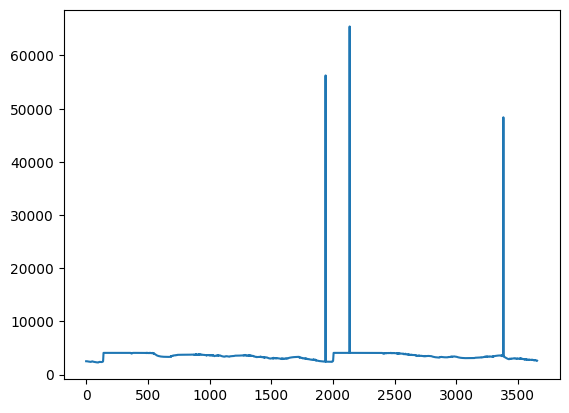

In [67]:
fs01_x_values=[]
fs02_x_values=[]

for i in range(0,fs01_count):
    fs01_x_values.append(i)
    
for i in range(0,fs02_count):
    fs02_x_values.append(i)

plt.plot(fs01_x_values,values_dates_fs01_ordered['value'])
#plt.plot(fs02_x_values,fs02_dec_value)

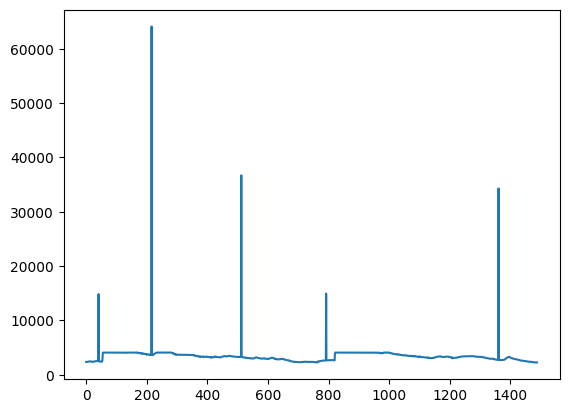

In [68]:
plt.plot(fs02_x_values,values_dates_fs02_ordered['value'])
#plt.plot(fs02_x_values,fs02_dec_value)

In [69]:
for i in range(0,values_dates_fs01.shape[0]):
    if int(values_dates_fs01.iloc[i,0])>4095:
        print(values_dates_fs01.iloc[i,2],values_dates_fs01.iloc[i,0])

0x2525210022359C086948706018799326100516563700013E01F71BBADBEEBBEBA719 56250
0x252521002036AE086948706018799326100615461500013E010719AFFFE8FF35 65455
0x25252100223D82086948706018799326100812000601013E01071BFDBCDD0A93AC6F 48381


In [70]:
for i in range(0,values_dates_fs02.shape[0]):
    if int(values_dates_fs02.iloc[i,0])>4095:
        print(values_dates_fs01.iloc[i,2],values_dates_fs02.iloc[i,0])

0x25252100202B25086948706018799326100115134801013E01071A770971977C 14847
0x25252100202C1B086948706018799326100120270501013E01071DFF0FFFFF6D 64096
0x25252100202DB9086948706018799326100205032301013E01071EDF0FF3FDA2 36707
0x25252100202F46086948706018799326100213202600013E01071CA10E10EA09 14954
0x25252100203269086948706018799326100318220000013E01071C6A0DA2D6CE 34300


In [71]:
gallons_fs01=[] #Editable
gallons_fs02=[] #Editable
m1=0.0836       #Editable
b1=0.3113      #Editable
m2=0.0836       #Editable
b2=0.3113       #Editable

values_dates_fs01_ordered.info()

for i in range(0,values_dates_fs01_ordered.shape[0]):
    gallons_value_fs01=(float(values_dates_fs01_ordered.iloc[i,0]*m1-b1)/3.785412)
    gallons_fs01.append(gallons_value_fs01) 
    #print(i,values_dates_fs01_ordered.iloc[i,2][32:44],(values_dates_fs01_ordered.iloc[i,0]*m1-b1)/3.785412)

for i in range(0,values_dates_fs02_ordered.shape[0]):
    gallons_value_fs02=(float(values_dates_fs02_ordered.iloc[i,0]*m2-b2)/3.785412)
    gallons_fs02.append(gallons_value_fs02)  
    #print(i,values_dates_fs02_ordered.iloc[i,2][32:44],(values_dates_fs02_ordered.iloc[i,0]*m1-b1)/3.785412)

values_dates_fs01_ordered['gallons']=gallons_fs01
values_dates_fs02_ordered['gallons']=gallons_fs02

<class 'pandas.DataFrame'>
RangeIndex: 3656 entries, 0 to 3655
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   value     3656 non-null   int64
 1   date      3656 non-null   str  
 2   raw data  3656 non-null   str  
dtypes: int64(1), str(2)
memory usage: 85.8 KB


In [72]:
capacity_1=90       #Editable
capacity_2=90       #Editable
level=0
p=0 # If vahice is parked, p=0

date1=260930164716  #Editable
date2=261008164716  #Editable

print("Tank 1: ")
print("Raising/Droping","->","end gallons","->","initial gallons","->","new_delta + old_delta")
for i in range(0,values_dates_fs01_ordered.shape[0]):
    if int(values_dates_fs01_ordered.iloc[i,1])>=date1 and int(values_dates_fs01_ordered.iloc[i,1])<=date2:
        #print(i,values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3])
        if values_dates_fs01_ordered.iloc[i+1,3]>=(values_dates_fs01_ordered.iloc[i,3]+(p/100)*capacity_1):
            level=values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3]+level
            print("raising",values_dates_fs01_ordered.iloc[i+1,3],values_dates_fs01_ordered.iloc[i,3],level)
        if values_dates_fs01_ordered.iloc[i+1,3]<=(values_dates_fs01_ordered.iloc[i,3]-(p/100)*capacity_1):
            level=values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3]+level
            print("droping",values_dates_fs01_ordered.iloc[i+1,3],values_dates_fs01_ordered.iloc[i,3],level)
print("Level change tank 1: ",level)

print("Level change tank 1 + Level change tank 2: ")
for i in range(0,values_dates_fs02_ordered.shape[0]):
    if int(values_dates_fs02_ordered.iloc[i,1])>=date1 and int(values_dates_fs02_ordered.iloc[i,1])<=date2:
        #print(i,values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3])
        if values_dates_fs02_ordered.iloc[i+1,3]>=(values_dates_fs02_ordered.iloc[i,3]+(p/100)*capacity_2):
            level=values_dates_fs02_ordered.iloc[i+1,3]-values_dates_fs02_ordered.iloc[i,3]+level
            print("raising",values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3],level)
        if values_dates_fs02_ordered.iloc[i+1,3]<=(values_dates_fs02_ordered.iloc[i,3]-(p/100)*capacity_2):
            level=values_dates_fs02_ordered.iloc[i+1,3]-values_dates_fs02_ordered.iloc[i,3]+level
            print("droping",values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3],level)

print("Level change toal: ",level)

Tank 1: 
Raising/Droping -> end gallons -> initial gallons -> new_delta + old_delta
raising 55.65975381279501 55.65975381279501 0.0
droping 55.65975381279501 55.65975381279501 0.0
raising 55.65975381279501 55.65975381279501 0.0
droping 55.65975381279501 55.65975381279501 0.0
raising 55.72600815974589 55.65975381279501 0.06625434695087762
raising 55.85851685364763 55.72600815974589 0.19876304085261864
droping 55.52724511889327 55.85851685364763 -0.13250869390174103
raising 56.035195112183295 55.52724511889327 0.3754412993882852
droping 55.65975381279501 56.035195112183295 0.0
droping 55.57141468352719 55.65975381279501 -0.08833912926782261
droping 55.43890598962543 55.57141468352719 -0.22084782316957785
droping 55.306397295723684 55.43890598962543 -0.353356517071326
droping 55.151803819504984 55.306397295723684 -0.5079499932900262
droping 55.041379907920195 55.151803819504984 -0.6183739048748151
droping 54.90887121401845 55.041379907920195 -0.7508825987765633
droping 54.79844730243366 5

Adding the validation to delete the value that beongs to ragistger i+1.

In [73]:
print("Tank 1: ")
print("Raising/Droping","->","end gallons","->","initial gallons","->","new_delta + old_delta","->","delta")
for i in range(0,values_dates_fs01_ordered.shape[0]):
    if int(values_dates_fs01_ordered.iloc[i,1])>=date1 and int(values_dates_fs01_ordered.iloc[i,1])<=date2:
        #print(i,values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3])
        if values_dates_fs01_ordered.iloc[i+1,3]>(values_dates_fs01_ordered.iloc[i,3]+(p/100)*capacity_1):
            level=values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3]+level
            print("raising",values_dates_fs01_ordered.iloc[i+1,3],values_dates_fs01_ordered.iloc[i,3],level,values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3])
        if values_dates_fs01_ordered.iloc[i+1,3]<(values_dates_fs01_ordered.iloc[i,3]-(p/100)*capacity_1):
            level=values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3]+level
            print("droping",values_dates_fs01_ordered.iloc[i+1,3],values_dates_fs01_ordered.iloc[i,3],level,values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3])
        if int(values_dates_fs01_ordered.iloc[i+1,1])>date2:
            level=level-float(values_dates_fs01_ordered.iloc[i+1,3]-float(values_dates_fs01_ordered.iloc[i,3]))
print("Level change tank 1: ",level)

print("Level change tank 1 + Level change tank 2: ")
for i in range(0,values_dates_fs02_ordered.shape[0]):
    if int(values_dates_fs02_ordered.iloc[i,1])>=date1 and int(values_dates_fs02_ordered.iloc[i,1])<=date2:
        #print(i,values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3])
        if values_dates_fs02_ordered.iloc[i+1,3]>(values_dates_fs02_ordered.iloc[i,3]+(p/100)*capacity_2):
            level=values_dates_fs02_ordered.iloc[i+1,3]-values_dates_fs02_ordered.iloc[i,3]+level
            print("raising",values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3],level,values_dates_fs02_ordered.iloc[i+1,3]-values_dates_fs02_ordered.iloc[i,3])
        if values_dates_fs02_ordered.iloc[i+1,3]<(values_dates_fs02_ordered.iloc[i,3]-(p/100)*capacity_2):
            level=values_dates_fs02_ordered.iloc[i+1,3]-values_dates_fs02_ordered.iloc[i,3]+level
            print("droping",values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3],level,values_dates_fs02_ordered.iloc[i+1,3]-values_dates_fs02_ordered.iloc[i,3])
        if int(values_dates_fs02_ordered.iloc[i+1,1])>date2:
            level=level-float(values_dates_fs02_ordered.iloc[i+1,3]-float(values_dates_fs02_ordered.iloc[i,3]))

print("Level change toal: ",level)

Tank 1: 
Raising/Droping -> end gallons -> initial gallons -> new_delta + old_delta -> delta
raising 55.72600815974589 55.65975381279501 12.720834614567927 0.06625434695087762
raising 55.85851685364763 55.72600815974589 12.853343308469668 0.13250869390174103
droping 55.52724511889327 55.85851685364763 12.522071573715309 -0.33127173475435967
raising 56.035195112183295 55.52724511889327 13.030021567005335 0.5079499932900262
droping 55.65975381279501 56.035195112183295 12.65458026761705 -0.3754412993882852
droping 55.57141468352719 55.65975381279501 12.566241138349227 -0.08833912926782261
droping 55.43890598962543 55.57141468352719 12.433732444447472 -0.13250869390175524
droping 55.306397295723684 55.43890598962543 12.301223750545724 -0.13250869390174813
droping 55.151803819504984 55.306397295723684 12.146630274327023 -0.15459347621870023
droping 55.041379907920195 55.151803819504984 12.036206362742234 -0.11042391158478893
droping 54.90887121401845 55.041379907920195 11.903697668840486 -0

In [74]:
print("Tank 1: ")
print("Raising/Droping","->","end gallons","->","initial gallons","->","new_delta + old_delta","->","delta")
for i in range(0,values_dates_fs01_ordered.shape[0]):
    if int(values_dates_fs01_ordered.iloc[i,1])>=date1 and int(values_dates_fs01_ordered.iloc[i,1])<=date2:
        #print(i,values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3])
        if values_dates_fs01_ordered.iloc[i+1,3]>(values_dates_fs01_ordered.iloc[i,3]+(p/100)*capacity_1):
            delta=values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3]
            level=delta+level
            print("raising",values_dates_fs01_ordered.iloc[i+1,3],values_dates_fs01_ordered.iloc[i,3],level,values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3])
        if values_dates_fs01_ordered.iloc[i+1,3]<(values_dates_fs01_ordered.iloc[i,3]-(p/100)*capacity_1):
            delta=values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3]
            level=delta+level
            print("droping",values_dates_fs01_ordered.iloc[i+1,3],values_dates_fs01_ordered.iloc[i,3],level,values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3])
        if int(values_dates_fs01_ordered.iloc[i+1,1])>date2:
            level=level-float(values_dates_fs01_ordered.iloc[i+1,3]-float(values_dates_fs01_ordered.iloc[i,3]))
print("Level change tank 1: ",level)

print("Level change tank 1 + Level change tank 2: ")
for i in range(0,values_dates_fs02_ordered.shape[0]):
    if int(values_dates_fs02_ordered.iloc[i,1])>=date1 and int(values_dates_fs02_ordered.iloc[i,1])<=date2:
        #print(i,values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3])
        if values_dates_fs02_ordered.iloc[i+1,3]>(values_dates_fs02_ordered.iloc[i,3]+(p/100)*capacity_2):
            delta=values_dates_fs02_ordered.iloc[i+1,3]-values_dates_fs02_ordered.iloc[i,3]
            level=delta+level
            print("raising",values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3],level,delta)
        if values_dates_fs02_ordered.iloc[i+1,3]<(values_dates_fs02_ordered.iloc[i,3]-(p/100)*capacity_2):
            delta=values_dates_fs02_ordered.iloc[i+1,3]-values_dates_fs02_ordered.iloc[i,3]
            level=delta+level
            print("droping",values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3],level,delta)
        if int(values_dates_fs02_ordered.iloc[i+1,1])>date2:
            level=level-float(values_dates_fs02_ordered.iloc[i+1,3]-float(values_dates_fs02_ordered.iloc[i,3]))

print("Level change toal: ",level)

Tank 1: 
Raising/Droping -> end gallons -> initial gallons -> new_delta + old_delta -> delta
raising 55.72600815974589 55.65975381279501 25.728771399256175 0.06625434695087762
raising 55.85851685364763 55.72600815974589 25.861280093157916 0.13250869390174103
droping 55.52724511889327 55.85851685364763 25.530008358403556 -0.33127173475435967
raising 56.035195112183295 55.52724511889327 26.037958351693582 0.5079499932900262
droping 55.65975381279501 56.035195112183295 25.662517052305297 -0.3754412993882852
droping 55.57141468352719 55.65975381279501 25.574177923037475 -0.08833912926782261
droping 55.43890598962543 55.57141468352719 25.44166922913572 -0.13250869390175524
droping 55.306397295723684 55.43890598962543 25.30916053523397 -0.13250869390174813
droping 55.151803819504984 55.306397295723684 25.15456705901527 -0.15459347621870023
droping 55.041379907920195 55.151803819504984 25.044143147430482 -0.11042391158478893
droping 54.90887121401845 55.041379907920195 24.911634453528734 -0.1

Create a report as dataframe

In [75]:
delta_aux=[]
x_after=[]
x_=[]

df_report=pd.DataFrame()

print("Tank 1: ")
print("Raising/Droping","->","end gallons","->","initial gallons","->","new_delta + old_delta","->","delta")
for i in range(0,values_dates_fs01_ordered.shape[0]):
    if int(values_dates_fs01_ordered.iloc[i,1])>=date1 and int(values_dates_fs01_ordered.iloc[i,1])<=date2:
        #print(i,values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3])
        if values_dates_fs01_ordered.iloc[i+1,3]>(values_dates_fs01_ordered.iloc[i,3]+(p/100)*capacity_1):            
            delta=values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3]
            delta_aux.append(delta)
            x_after.append(values_dates_fs01_ordered.iloc[i+1,3])
            x_.append(values_dates_fs01_ordered.iloc[i,3])
            level=delta+level
            print("raising",values_dates_fs01_ordered.iloc[i+1,3],values_dates_fs01_ordered.iloc[i,3],level,values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3])
        if values_dates_fs01_ordered.iloc[i+1,3]<(values_dates_fs01_ordered.iloc[i,3]-(p/100)*capacity_1):
            delta=values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3]
            delta_aux.append(delta)
            x_after.append(values_dates_fs01_ordered.iloc[i+1,3])
            x_.append(values_dates_fs01_ordered.iloc[i,3])
            level=delta+level
            print("droping",values_dates_fs01_ordered.iloc[i+1,3],values_dates_fs01_ordered.iloc[i,3],level,values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3])
        if int(values_dates_fs01_ordered.iloc[i+1,1])>date2:
            level=level-float(values_dates_fs01_ordered.iloc[i+1,3]-float(values_dates_fs01_ordered.iloc[i,3]))
print("Level change tank 1: ",level)

print("Level change tank 1 + Level change tank 2: ")
for i in range(0,values_dates_fs02_ordered.shape[0]):
    if int(values_dates_fs02_ordered.iloc[i,1])>=date1 and int(values_dates_fs02_ordered.iloc[i,1])<=date2:
        #print(i,values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3])
        if values_dates_fs02_ordered.iloc[i+1,3]>(values_dates_fs02_ordered.iloc[i,3]+(p/100)*capacity_2):
            delta=values_dates_fs02_ordered.iloc[i+1,3]-values_dates_fs02_ordered.iloc[i,3]
            delta_aux.append(delta)
            x_after.append(values_dates_fs01_ordered.iloc[i+1,3])
            x_.append(values_dates_fs01_ordered.iloc[i,3])
            level=delta+level
            print("raising",values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3],level,delta)
        if values_dates_fs02_ordered.iloc[i+1,3]<(values_dates_fs02_ordered.iloc[i,3]-(p/100)*capacity_2):
            delta=values_dates_fs02_ordered.iloc[i+1,3]-values_dates_fs02_ordered.iloc[i,3]
            delta_aux.append(delta)
            x_after.append(values_dates_fs01_ordered.iloc[i+1,3])
            x_.append(values_dates_fs01_ordered.iloc[i,3])
            level=delta+level
            print("droping",values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3],level,delta)
        if int(values_dates_fs02_ordered.iloc[i+1,1])>date2:
            level=level-float(values_dates_fs02_ordered.iloc[i+1,3]-float(values_dates_fs02_ordered.iloc[i,3]))

df_report['x_']=x_
df_report['x_after']=x_after
df_report['delta']=delta_aux

df_report

Tank 1: 
Raising/Droping -> end gallons -> initial gallons -> new_delta + old_delta -> delta
raising 55.72600815974589 55.65975381279501 38.73670818394453 0.06625434695087762
raising 55.85851685364763 55.72600815974589 38.86921687784627 0.13250869390174103
droping 55.52724511889327 55.85851685364763 38.53794514309191 -0.33127173475435967
raising 56.035195112183295 55.52724511889327 39.04589513638194 0.5079499932900262
droping 55.65975381279501 56.035195112183295 38.67045383699365 -0.3754412993882852
droping 55.57141468352719 55.65975381279501 38.58211470772583 -0.08833912926782261
droping 55.43890598962543 55.57141468352719 38.449606013824074 -0.13250869390175524
droping 55.306397295723684 55.43890598962543 38.317097319922325 -0.13250869390174813
droping 55.151803819504984 55.306397295723684 38.162503843703625 -0.15459347621870023
droping 55.041379907920195 55.151803819504984 38.052079932118836 -0.11042391158478893
droping 54.90887121401845 55.041379907920195 37.91957123821709 -0.13250

,x_,x_after,delta
0,55.659754,55.726008,0.066254
1,55.726008,55.858517,0.132509
2,55.858517,55.527245,-0.331272
3,55.527245,56.035195,0.507950
4,56.035195,55.659754,-0.375441
...,...,...,...
3578,71.671221,71.781645,-0.485865
3579,71.781645,71.693306,0.066254
3580,71.693306,71.604967,0.220848
3581,71.604967,71.185356,0.198763
